# `02_feature_engineering.ipynb` — Updated Skeleton

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import mlflow
import os

# --- Utility: Haversine distance ---
def haversine(lon1, lat1, lon2, lat2):
    R = 6371  # Earth radius in km
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# --- Load raw dataset ---
df = pd.read_csv("../data/raw/nyc_taxi.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## Validation

In [2]:
# Remove invalid rows
df = df.dropna()
df = df[df['trip_duration'] > 60]      # > 1 min
df = df[df['trip_duration'] < 86400]   # < 24 hrs
print("Rows after validation:", len(df))


Rows after validation: 1449863


## Feature Engineering

In [3]:
# Time features
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour_of_day'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.weekday
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Distance feature
df['trip_distance_km'] = df.apply(
    lambda row: haversine(row['pickup_longitude'], row['pickup_latitude'],
                          row['dropoff_longitude'], row['dropoff_latitude']), axis=1)

# Traffic feature
df['rush_hour'] = df['hour_of_day'].isin([7,8,9,17,18,19]).astype(int)

# Synthetic weather (for demo purposes)
np.random.seed(42)
df['weather'] = np.random.choice(['sunny', 'rainy', 'cloudy'], size=len(df))

df.head()


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour_of_day,day_of_week,is_weekend,trip_distance_km,rush_hour,weather
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,0,1.498521,1,cloudy
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,1,1.805507,0,sunny
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,0,6.385098,0,cloudy
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,0,1.485498,1,cloudy
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,1,1.188588,0,sunny


## Visualizations

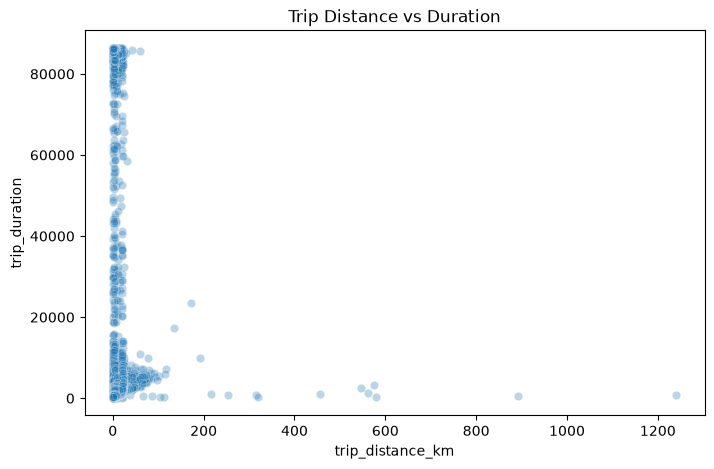

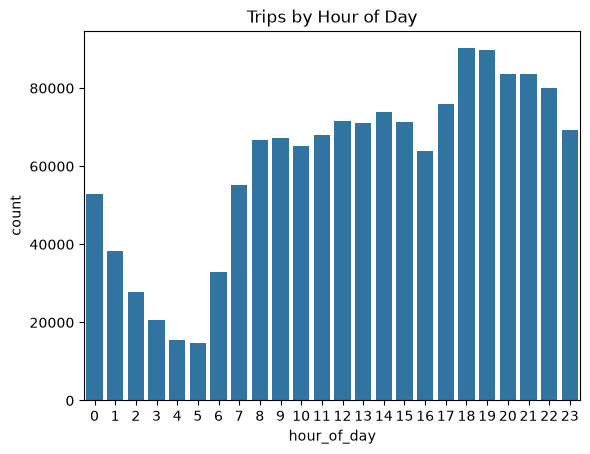

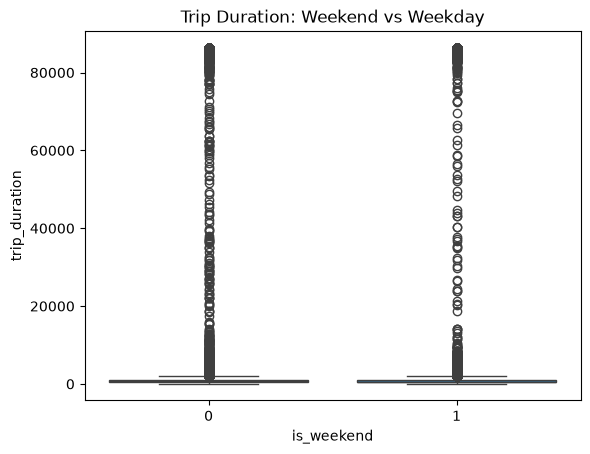

In [4]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='trip_distance_km', y='trip_duration', data=df, alpha=0.3)
plt.title("Trip Distance vs Duration")
plt.show()

sns.countplot(x='hour_of_day', data=df)
plt.title("Trips by Hour of Day")
plt.show()

sns.boxplot(x='is_weekend', y='trip_duration', data=df)
plt.title("Trip Duration: Weekend vs Weekday")
plt.show()


## MLflow Integration

2026/08/23 18:53:00 INFO mlflow.tracking.fluent: Experiment with name 'FeatureEngineering' does not exist. Creating a new experiment.


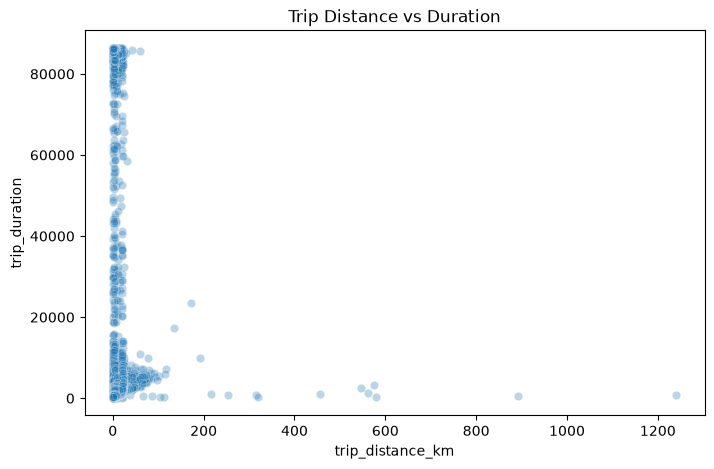

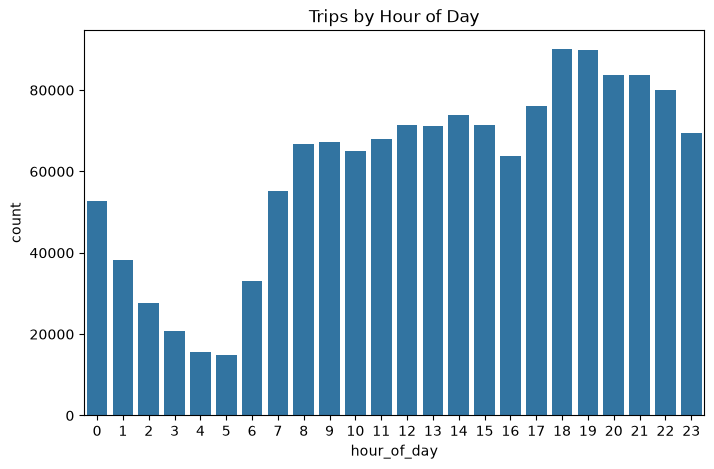

In [5]:
# Set MLflow tracking to SQLite backend
mlflow.set_tracking_uri("sqlite:///../logs/mlflow.db")
mlflow.set_experiment("FeatureEngineering")

with mlflow.start_run(run_name="FeatureEngineeringNotebook"):
    # Save engineered sample
    df.head(100).to_csv("../logs/engineered_sample.csv", index=False)
    mlflow.log_artifact("../logs/engineered_sample.csv", artifact_path="features")

    # Save plots
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='trip_distance_km', y='trip_duration', data=df, alpha=0.3)
    plt.title("Trip Distance vs Duration")
    plot_path = "../logs/distance_vs_duration.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path, artifact_path="plots")

    plt.figure(figsize=(8,5))
    sns.countplot(x='hour_of_day', data=df)
    plt.title("Trips by Hour of Day")
    plot_path = "../logs/trips_by_hour.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path, artifact_path="plots")


## What This Notebook Now Does

• Validates raw data (removes invalid trips).

• Engineers features (hour_of_day, day_of_week, is_weekend, trip_distance_km, rush_hour, weather).

• Visualizes feature relationships.

• Logs engineered dataset samples + plots into MLflow for traceability.
